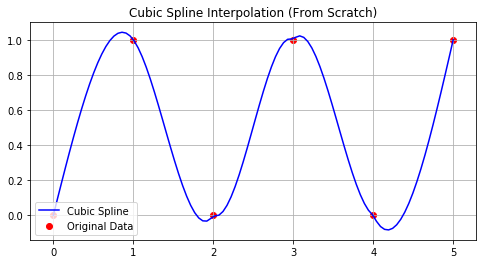

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 1: Define Known Data Points ---
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])
n = len(x)

# --- STEP 2: Calculate Step Sizes ---
h = np.diff(x)

# --- STEP 3: Set Up and Solve the Tridiagonal System ---
def thomas_algorithm(a, b, c, d):
    nf = len(d)
    # Forward elimination
    for i in range(1, nf):
        m = a[i-1] / b[i-1]
        b[i] = b[i] - m * c[i-1]
        d[i] = d[i] - m * d[i-1]
    # Back substitution
    res = np.zeros(nf)
    res[-1] = d[-1] / b[-1]
    for i in range(nf-2, -1, -1):
        res[i] = (d[i] - c[i] * res[i+1]) / b[i]
    return res

# Build A, B, C, D for internal points (i=1 to n-2 in 0-indexing)
A = h[:-1] 
B = 2 * (h[:-1] + h[1:])
C = h[1:]
D = 6 * (np.diff(y)[1:]/h[1:] - np.diff(y)[:-1]/h[:-1])

# Solve for M (second derivatives)
M_internal = thomas_algorithm(A, B, C, D)
# Natural Spline: M[0] = M[n-1] = 0
M = np.concatenate(([0], M_internal, [0]))

# --- STEP 4: Evaluate the Spline at New Points ---
def evaluate_spline(x_eval, x, y, h, M):
    # Find the interval index
    i = np.searchsorted(x, x_eval) - 1
    i = np.clip(i, 0, len(h) - 1)
    
    dx = x_eval - x[i]
    # Calculate coefficients
    ai = y[i]
    ci = M[i] / 2.0
    di = (M[i+1] - M[i]) / (6.0 * h[i])
    bi = (y[i+1] - y[i]) / h[i] - (h[i] * (2.0 * M[i] + M[i+1])) / 6.0
    
    return ai + bi*dx + ci*dx**2 + di*dx**3

# --- PLOT THE RESULTS ---
x_fine = np.linspace(x[0], x[-1], 100)
y_fine = [evaluate_spline(val, x, y, h, M) for val in x_fine]

plt.figure(figsize=(8, 4))
plt.plot(x_fine, y_fine, label='Cubic Spline', color='blue')
plt.scatter(x, y, color='red', label='Original Data')
plt.title("Cubic Spline Interpolation (From Scratch)")
plt.legend()
plt.grid(True)
plt.show()